In [213]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

In [214]:
np.random.seed(42)
torch.manual_seed(42)

In [215]:
iris = load_iris()
X = iris.data               # shape (150, 4)
y = iris.target             # shape (150,)

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# Standardize features
scaler      = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std  = scaler.transform(X_test)

# Convert to torch tensors
X_train_t = torch.tensor(X_train_std, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_std,  dtype=torch.float32)
y_train_t = torch.tensor(y_train,     dtype=torch.long)
y_test_t  = torch.tensor(y_test,      dtype=torch.long)

### 2.2 NumPy MLP Forward & Backward

In [216]:
def one_hot(y, num_classes=3):
    Y = np.zeros((y.size, num_classes))
    Y[np.arange(y.size), y] = 1
    return Y

Y_train_oh = one_hot(y_train, num_classes=3)

In [217]:
input_dim, hidden_dim1, hidden_dim2, output_dim = 4, 10, 10, 3
lr_np       = 10
epochs_np   = 500

# Initialize parameters
rng = np.random.RandomState(42)
W1 = rng.randn(input_dim, hidden_dim1) * 0.01
b1 = np.zeros((1, hidden_dim1))
W2 = rng.randn(hidden_dim1, hidden_dim2) * 0.01
b2 = np.zeros((1, hidden_dim2))
W3 = rng.randn(hidden_dim2, output_dim) * 0.01
b3 = np.zeros((1, output_dim))

In [218]:
# Activation / loss / grads
def sigmoid(x):
    # TODO: implement the sigmoid activation
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    # TODO: implement the derivative of sigmoid
    x = np.clip(x, -500, 500)
    s = sigmoid(x)
    return s * (1 - s)

def softmax(x):
    # TODO: implement softmax over each row
    exps = np.exp(x - x.max(axis=-1, keepdims=True))
    return exps / np.sum(exps, axis=-1, keepdims=True)

def cross_entropy_loss(Y_true, P_pred):
    """
    Y_true: one‑hot labels, shape (N, C)
    P_pred: softmax probabilities, shape (N, C)
    """
    # TODO: compute average cross‑entropy loss
    eps = 1e-8
    return -np.mean(np.sum(Y_true * np.log(P_pred + eps), axis=-1))


def compute_loss_and_grads(Xb, Yb, W1, b1, W2, b2, W3, b3):
    N = Xb.shape[0]
    C = W3.shape[1]

    # TODO: forward pass (sigmoid layers + softmax output)
    z1 = np.matmul(Xb, W1) + b1 # (n, d1) (d1, d2)
    a1 = sigmoid(z1)
    z2 = np.matmul(a1, W2) + b2 # (n , d2) (d2, d3)
    a2 = sigmoid(z2)
    z3 = np.matmul(a2, W3) + b3 # (n , d3) (d3, C)
    y_prob = softmax(z3)
    y_pred = y_prob.argmax(-1)
    yb_oh = one_hot(Yb, C)
    
    # TODO: compute loss
    
    loss = cross_entropy_loss(yb_oh, y_prob)

    # TODO: backward pass to compute dW3, db3, dW2, db2, dW1, db1
    dl_z3 = (y_prob - yb_oh) / N # (N, C)
    db3 = np.sum(dl_z3, axis=0, keepdims=True)
    dW3 = np.matmul(a2.T, dl_z3)
    da2 = np.matmul(dl_z3, W3.T) #n, d3
    dz2 = sigmoid_grad(z2) * da2
    db2 = np.sum(dz2, axis=0, keepdims=True)
    dW2 = np.matmul(a1.T, dz2)
    da1 = np.matmul(dz2, W2.T)
    dz1 = sigmoid_grad(z1) * da1
    db1 = np.sum(dz1, axis=0, keepdims=True)
    dW1 = np.matmul(Xb.T, dz1)
    
    return loss, dW1, db1, dW2, db2, dW3, db3, y_pred

i = 0
loss_np, dW1_np, db1_np, dW2_np, db2_np, dW3_np, db3_np, _ = compute_loss_and_grads(
    X_train_std[i:i+1], y_train[i:i+1] , W1, b1, W2, b2, W3, b3, 
)

print("NumPy gradient shapes:",
      "\ndW1:", dW1_np.shape,
      "\ndb1:", db1_np.shape,
      "\ndW2:", dW2_np.shape,
      "\ndb2:", db2_np.shape,
      "\ndW3:", dW3_np.shape,
      "\ndb3:", db3_np.shape)

NumPy gradient shapes: 
dW1: (4, 10) 
db1: (1, 10) 
dW2: (10, 10) 
db2: (1, 10) 
dW3: (10, 3) 
db3: (1, 3)


In [219]:
(len(X_train_std)* 500)/500

112.0

In [220]:
loss_hist_np = []
epoch_num = 0
for epoch in range(epochs_np * len(X_train_std)):

    # TODO: call compute_loss_and_grads on the full batch
    loss_np, dW1_np, db1_np, dW2_np, db2_np, dW3_np, db3_np, _ = compute_loss_and_grads(
        X_train_std, y_train , W1, b1, W2, b2, W3, b3
        )

    # TODO: update parameters W1, b1, W2, b2, W3, b3 using gradients and lr_np
    W1 -= lr_np * dW1_np
    b1 -= lr_np * db1_np
    W2 -= lr_np * dW2_np
    b2 -= lr_np * db2_np
    W3 -= lr_np * dW3_np
    b3 -= lr_np * db3_np

    if (epoch) % len(X_train_std) == 1:
        loss_hist_np.append(loss_np)
        
        epoch_num += 1
        if epoch_num % 10 == 0:
            
            print(f"[NumPy] Epoch {epoch_num}/{epochs_np}, Loss: {loss_np:.6f}")


[NumPy] Epoch 10/500, Loss: 1.018996
[NumPy] Epoch 20/500, Loss: 1.018997
[NumPy] Epoch 30/500, Loss: 1.018997
[NumPy] Epoch 40/500, Loss: 1.018997
[NumPy] Epoch 50/500, Loss: 1.018996
[NumPy] Epoch 60/500, Loss: 1.018996
[NumPy] Epoch 70/500, Loss: 1.018996
[NumPy] Epoch 80/500, Loss: 1.018996
[NumPy] Epoch 90/500, Loss: 1.018996
[NumPy] Epoch 100/500, Loss: 1.018996
[NumPy] Epoch 110/500, Loss: 1.018996
[NumPy] Epoch 120/500, Loss: 1.018996
[NumPy] Epoch 130/500, Loss: 1.018996
[NumPy] Epoch 140/500, Loss: 1.018996
[NumPy] Epoch 150/500, Loss: 1.018996
[NumPy] Epoch 160/500, Loss: 1.018996
[NumPy] Epoch 170/500, Loss: 1.018996
[NumPy] Epoch 180/500, Loss: 1.018996
[NumPy] Epoch 190/500, Loss: 1.018996
[NumPy] Epoch 200/500, Loss: 1.018995
[NumPy] Epoch 210/500, Loss: 1.018995
[NumPy] Epoch 220/500, Loss: 1.018994
[NumPy] Epoch 230/500, Loss: 1.018993
[NumPy] Epoch 240/500, Loss: 1.018992
[NumPy] Epoch 250/500, Loss: 1.018986
[NumPy] Epoch 260/500, Loss: 1.019237
[NumPy] Epoch 270/500

In [221]:
# Evaluate NumPy model

# TODO: forward pass on X_test_std to compute preds_np
loss_np, dW1_np, db1_np, dW2_np, db2_np, dW3_np, db3_np, preds_np = compute_loss_and_grads(
    X_test_std, y_test , W1, b1, W2, b2, W3, b3
    )
acc_np   = np.mean(preds_np == y_test)
print(f"\n[NumPy] Test Accuracy: {acc_np:.4f}\n")


[NumPy] Test Accuracy: 0.9211



### PyTorch MLP with Sigmoid + CrossEntropyLoss

In [222]:
class IrisNet(nn.Module):
    def __init__(self, input_dim=4, h1=10, h2=10, out_dim=3):
        super().__init__()
        # TODO: define self.fc1, self.act1, self.fc2, self.act2, self.fc3
        self.fc1 = nn.Linear(input_dim, h1)
        self.act1 = nn.Sigmoid()
        self.fc2 = nn.Linear(h1, h2)
        self.act2 = nn.Sigmoid()
        self.fc3 = nn.Linear(h2, out_dim)

    def forward(self, x):
        # TODO: implement forward using nn.Sigmoid activations
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.fc3(x)
        return x


In [223]:
# TODO: instantiate model, criterion, optimizer
from numpy import dtype


model = IrisNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=10)
epochs_pt = 500
loss_hist_pt = []

for epoch in range(epochs_pt):

    # TODO: standard PyTorch training loop
    
    optimizer.zero_grad()
    y_pred = model(torch.tensor(X_test_std, dtype=torch.float32))
    loss = criterion(y_pred, torch.tensor(y_test))
    loss.backward()
    optimizer.step()
    loss_hist_pt.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"[PyTorch] Epoch {epoch+1}/{epochs_pt}, Loss: {loss.item():.4f}")


[PyTorch] Epoch 10/500, Loss: 1.5412
[PyTorch] Epoch 20/500, Loss: 1.0906
[PyTorch] Epoch 30/500, Loss: 1.0967
[PyTorch] Epoch 40/500, Loss: 1.0975
[PyTorch] Epoch 50/500, Loss: 1.1020
[PyTorch] Epoch 60/500, Loss: 1.1044
[PyTorch] Epoch 70/500, Loss: 1.1069
[PyTorch] Epoch 80/500, Loss: 1.1106
[PyTorch] Epoch 90/500, Loss: 1.1046
[PyTorch] Epoch 100/500, Loss: 1.0814
[PyTorch] Epoch 110/500, Loss: 0.8362
[PyTorch] Epoch 120/500, Loss: 0.6594
[PyTorch] Epoch 130/500, Loss: 0.5756
[PyTorch] Epoch 140/500, Loss: 0.0789
[PyTorch] Epoch 150/500, Loss: 1.3358
[PyTorch] Epoch 160/500, Loss: 0.0950
[PyTorch] Epoch 170/500, Loss: 0.0739
[PyTorch] Epoch 180/500, Loss: 0.0087
[PyTorch] Epoch 190/500, Loss: 0.0065
[PyTorch] Epoch 200/500, Loss: 0.0054
[PyTorch] Epoch 210/500, Loss: 0.0046
[PyTorch] Epoch 220/500, Loss: 0.0040
[PyTorch] Epoch 230/500, Loss: 0.0035
[PyTorch] Epoch 240/500, Loss: 0.0032
[PyTorch] Epoch 250/500, Loss: 0.0029
[PyTorch] Epoch 260/500, Loss: 0.0026
[PyTorch] Epoch 270/5

### Evaluate PyTorch model

In [224]:
loss_np, dW1_np, db1_np, dW2_np, db2_np, dW3_np, db3_np, preds_np = compute_loss_and_grads(
    X_test_std, y_test , W1, b1, W2, b2, W3, b3
    )

acc_pt = accuracy_score(y_test, preds_np)
print(f"\n[NumPy] Test Accuracy: {acc_pt:.4f}\n")
print("Classification Report (NumPy):")
print(classification_report(y_test, preds_np, target_names=iris.target_names))



[NumPy] Test Accuracy: 0.9211

Classification Report (NumPy):
              precision    recall  f1-score   support

      setosa       1.00      0.92      0.96        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.92        38
   macro avg       0.93      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



In [225]:
preds_pt = model(torch.tensor(X_test_std, dtype=torch.float32)).detach().numpy().argmax(-1)

acc_pt = accuracy_score(y_test, preds_pt)
print(f"\n[PyTorch] Test Accuracy: {acc_pt:.4f}\n")
print("Classification Report (PyTorch):")
print(classification_report(y_test, preds_pt, target_names=iris.target_names))


[PyTorch] Test Accuracy: 1.0000

Classification Report (PyTorch):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



### Visualizations

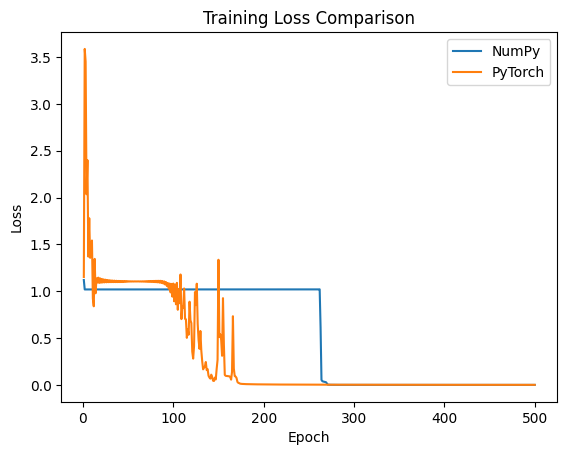

In [226]:
plt.figure()
plt.plot(range(1, epochs_np+1), loss_hist_np, label='NumPy')
plt.plot(range(1, epochs_pt+1), loss_hist_pt, label='PyTorch')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

